# Notebook 06: LIME Explanations

This notebook generates LIME explanations for the same selected Dry Bean test samples used in the SHAP notebook.

The main goal is to create local explanation outputs that can later be compared with SHAP explanations for explanation stability analysis.

LIME explanations are generated for all four trained models:

- Logistic Regression
- Decision Tree
- Random Forest
- MLP Neural Network


### Cell 1: Imports and Configs

In [1]:
from pathlib import Path
import json
import pickle
import random
import sys
import subprocess

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

NOTEBOOK_NAME = "06_lime_explanations"

FORCE_RECOMPUTE_LIME = False

LIME_NUM_SAMPLES = 5000
TOP_K_LOCAL_FEATURES = 5


def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

SHAP_RESULTS_DIR = PROJECT_ROOT / "results" / "05_shap_explanations"
RESULTS_DIR = PROJECT_ROOT / "results" / NOTEBOOK_NAME
PLOTS_DIR = PROJECT_ROOT / "plots" / NOTEBOOK_NAME
TRAINING_RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /home/iailab42/khans1/projects/xai
Results directory: /home/iailab42/khans1/projects/xai/results/06_lime_explanations
Plots directory: /home/iailab42/khans1/projects/xai/plots/06_lime_explanations


### Cell 2: Install and Import LIME

In [2]:
try:
    import lime
    import lime.lime_tabular
    print("LIME already installed.")
except ImportError:
    print("LIME is not installed. Installing LIME now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime"])
    import lime
    import lime.lime_tabular
    print("LIME installed successfully.")

LIME is not installed. Installing LIME now...
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 43.9 MB/s  0:00:00m0:00:01
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=e5fb0abe9ac41fa76d31544faddd55ff568dee9d839c00843c31ab1075fa9369
  Stored in directory: /home/iai/user/khans1/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lime]4/5 [lime]t-image]
LIME installed successfully.


### Cell 3 — Helper Functions

In [3]:
def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing JSON file: {path}")

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def save_json(data: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4)


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV file: {path}")

    return pd.read_csv(path)


def load_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing model file: {path}")

    return joblib.load(path)


def save_pickle(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "wb") as file:
        pickle.dump(obj, file)


def load_pickle(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing pickle file: {path}")

    with open(path, "rb") as file:
        return pickle.load(file)


def extract_feature_columns(feature_columns_raw):
    if isinstance(feature_columns_raw, dict) and "feature_columns" in feature_columns_raw:
        return feature_columns_raw["feature_columns"]

    if isinstance(feature_columns_raw, list):
        return feature_columns_raw

    raise ValueError(
        "feature_columns.json must be either a list or a dictionary with key 'feature_columns'."
    )

### Cell 4 — Load Data and Selected Samples

In [4]:
feature_columns_raw = load_json(DATA_PROCESSED_DIR / "feature_columns.json")
feature_columns = extract_feature_columns(feature_columns_raw)

X_train = load_csv(DATA_PROCESSED_DIR / "X_train.csv")
X_test = load_csv(DATA_PROCESSED_DIR / "X_test.csv")

X_train_scaled = load_csv(DATA_PROCESSED_DIR / "X_train_scaled.csv")
X_test_scaled = load_csv(DATA_PROCESSED_DIR / "X_test_scaled.csv")

y_train_full = load_csv(DATA_PROCESSED_DIR / "y_train.csv")
y_test_full = load_csv(DATA_PROCESSED_DIR / "y_test.csv")

selected_samples = load_csv(SHAP_RESULTS_DIR / "selected_samples.csv")

TARGET_COLUMN = "Class_encoded"

y_train = y_train_full[TARGET_COLUMN].reset_index(drop=True)
y_test = y_test_full[TARGET_COLUMN].reset_index(drop=True)

train_sample_ids = y_train_full["sample_id"].reset_index(drop=True)
test_sample_ids = y_test_full["sample_id"].reset_index(drop=True)

CLASS_ID_TO_NAME = {
    0: "BARBUNYA",
    1: "BOMBAY",
    2: "CALI",
    3: "DERMASON",
    4: "HOROZ",
    5: "SEKER",
    6: "SIRA"
}

CLASS_NAME_TO_ID = {
    class_name: class_id
    for class_id, class_name in CLASS_ID_TO_NAME.items()
}

class_names = [
    CLASS_ID_TO_NAME[class_id]
    for class_id in sorted(CLASS_ID_TO_NAME.keys())
]

print("Data and selected samples loaded successfully.")
print(f"Number of feature columns: {len(feature_columns)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"Selected samples shape: {selected_samples.shape}")

display(selected_samples.head())

Data and selected samples loaded successfully.
Number of feature columns: 16
X_train shape: (10834, 16)
X_test shape: (2709, 16)
X_train_scaled shape: (10834, 16)
X_test_scaled shape: (2709, 16)
Selected samples shape: (40, 8)


,sample_id,row_index,selected_from_model,selection_group,true_label,true_class_name,predicted_label,predicted_class_name_in_source_model
0,2573,192,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
1,2590,960,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
2,2591,66,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
3,2790,126,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
4,2883,553,mlp,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI


### Cell 5 — Load All Four Models and Prediction Files

In [5]:
models = {
    "logistic_regression": {
        "display_name": "Logistic Regression",
        "model": load_model(MODELS_DIR / "logistic_regression.pkl"),
        "uses_scaled_data": True
    },

    "decision_tree": {
        "display_name": "Decision Tree",
        "model": load_model(MODELS_DIR / "decision_tree.pkl"),
        "uses_scaled_data": False
    },

    "random_forest": {
        "display_name": "Random Forest",
        "model": load_model(MODELS_DIR / "random_forest.pkl"),
        "uses_scaled_data": False
    },

    "mlp": {
        "display_name": "MLP",
        "model": load_model(MODELS_DIR / "mlp.pkl"),
        "uses_scaled_data": True
    }
}

prediction_data = {}

for model_name in models.keys():
    prediction_path = TRAINING_RESULTS_DIR / f"{model_name}_predictions.csv"
    prediction_data[model_name] = load_csv(prediction_path)

print("All models and prediction files loaded successfully.")

for model_name, model_info in models.items():
    input_type = "scaled" if model_info["uses_scaled_data"] else "unscaled"
    print(f"{model_info['display_name']}: uses {input_type} data")

All models and prediction files loaded successfully.
Logistic Regression: uses scaled data
Decision Tree: uses unscaled data
Random Forest: uses unscaled data
MLP: uses scaled data


### Cell 6 — Validate Loaded Data

In [6]:
def validate_feature_columns(
    dataframe: pd.DataFrame,
    dataframe_name: str,
    expected_columns: list
):
    actual_columns = list(dataframe.columns)

    if actual_columns != expected_columns:
        missing_columns = set(expected_columns).difference(actual_columns)
        extra_columns = set(actual_columns).difference(expected_columns)

        print(f"\nColumn validation failed for: {dataframe_name}")
        print(f"Missing columns: {missing_columns}")
        print(f"Extra columns: {extra_columns}")

        raise ValueError(f"{dataframe_name} columns do not match feature columns.")

    print(f"{dataframe_name}: column validation passed.")


def validate_prediction_file(
    model_name: str,
    prediction_df: pd.DataFrame,
    expected_rows: int
):
    required_columns = {
        "sample_id",
        "true_label",
        "predicted_label"
    }

    missing_columns = required_columns.difference(prediction_df.columns)

    if missing_columns:
        raise ValueError(
            f"{model_name} prediction file is missing columns: {missing_columns}"
        )

    if len(prediction_df) != expected_rows:
        raise ValueError(
            f"{model_name} prediction file has {len(prediction_df)} rows, "
            f"but expected {expected_rows} rows."
        )

    print(f"{model_name}: prediction validation passed.")


required_selected_sample_columns = {
    "sample_id",
    "row_index",
    "selection_group",
    "true_label",
    "true_class_name"
}

missing_selected_columns = required_selected_sample_columns.difference(
    selected_samples.columns
)

if missing_selected_columns:
    raise ValueError(
        f"selected_samples.csv is missing columns: {missing_selected_columns}"
    )

validate_feature_columns(X_train, "X_train", feature_columns)
validate_feature_columns(X_test, "X_test", feature_columns)
validate_feature_columns(X_train_scaled, "X_train_scaled", feature_columns)
validate_feature_columns(X_test_scaled, "X_test_scaled", feature_columns)

for model_name, prediction_df in prediction_data.items():
    validate_prediction_file(
        model_name=model_name,
        prediction_df=prediction_df,
        expected_rows=len(X_test)
    )

if selected_samples["row_index"].isna().any():
    raise ValueError("selected_samples.csv contains missing row_index values.")

if selected_samples["row_index"].max() >= len(X_test):
    raise ValueError("selected_samples.csv contains row_index values outside X_test range.")

print("\nAll validation checks passed.")

X_train: column validation passed.
X_test: column validation passed.
X_train_scaled: column validation passed.
X_test_scaled: column validation passed.
logistic_regression: prediction validation passed.
decision_tree: prediction validation passed.
random_forest: prediction validation passed.
mlp: prediction validation passed.

All validation checks passed.


### Cell 7 — Prepare Model-Specific Data

In [7]:
selected_row_indices = selected_samples["row_index"].astype(int).tolist()

X_explain_unscaled = X_test.iloc[selected_row_indices].reset_index(drop=True)
X_explain_scaled = X_test_scaled.iloc[selected_row_indices].reset_index(drop=True)

model_input_data = {
    "logistic_regression": {
        "training_data": X_train_scaled,
        "explain_data": X_explain_scaled,
        "input_type": "scaled"
    },

    "decision_tree": {
        "training_data": X_train,
        "explain_data": X_explain_unscaled,
        "input_type": "unscaled"
    },

    "random_forest": {
        "training_data": X_train,
        "explain_data": X_explain_unscaled,
        "input_type": "unscaled"
    },

    "mlp": {
        "training_data": X_train_scaled,
        "explain_data": X_explain_scaled,
        "input_type": "scaled"
    }
}

print("Model-specific input data prepared.")

for model_name, data_info in model_input_data.items():
    print(
        f"{model_name}: training data = {data_info['training_data'].shape}, "
        f"explain data = {data_info['explain_data'].shape}, "
        f"input type = {data_info['input_type']}"
    )

Model-specific input data prepared.
logistic_regression: training data = (10834, 16), explain data = (40, 16), input type = scaled
decision_tree: training data = (10834, 16), explain data = (40, 16), input type = unscaled
random_forest: training data = (10834, 16), explain data = (40, 16), input type = unscaled
mlp: training data = (10834, 16), explain data = (40, 16), input type = scaled


### Cell 8 — Create LIME Explainers

In [8]:
lime_explainers = {}

for model_name, model_info in models.items():
    training_data = model_input_data[model_name]["training_data"]

    lime_explainers[model_name] = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.asarray(training_data),
        feature_names=feature_columns,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE
    )

    print(f"LIME explainer created for: {model_info['display_name']}")

LIME explainer created for: Logistic Regression
LIME explainer created for: Decision Tree
LIME explainer created for: Random Forest
LIME explainer created for: MLP


### Cell 9 — LIME Explanation Utility Functions

In [9]:
def get_predictions_for_selected_samples(model_name: str) -> pd.DataFrame:
    prediction_df = prediction_data[model_name]

    selected_predictions = selected_samples[["sample_id"]].merge(
        prediction_df[["sample_id", "predicted_label"]],
        on="sample_id",
        how="left"
    )

    if selected_predictions["predicted_label"].isna().any():
        raise ValueError(f"Missing predictions for selected samples in {model_name}")

    selected_predictions["predicted_label"] = selected_predictions["predicted_label"].astype(int)

    return selected_predictions


def explain_single_instance_with_lime(
    explainer,
    model,
    instance_values: np.ndarray,
    predicted_label: int,
    num_features: int,
    num_samples: int
):
    explanation = explainer.explain_instance(
        data_row=instance_values,
        predict_fn=model.predict_proba,
        labels=[predicted_label],
        num_features=num_features,
        num_samples=num_samples
    )

    explanation_map = explanation.as_map()[predicted_label]
    explanation_list = explanation.as_list(label=predicted_label)

    return explanation, explanation_map, explanation_list


def create_lime_rows_for_model(
    model_name: str,
    model_info: dict,
    explainer,
    num_features: int,
    num_samples: int
) -> tuple[pd.DataFrame, list]:
    model = model_info["model"]
    display_name = model_info["display_name"]

    explain_data = model_input_data[model_name]["explain_data"]
    input_type = model_input_data[model_name]["input_type"]

    selected_predictions = get_predictions_for_selected_samples(model_name)

    local_rows = []
    raw_explanation_records = []

    for sample_position in range(len(selected_samples)):
        selected_sample = selected_samples.iloc[sample_position]
        instance_values = explain_data.iloc[sample_position].to_numpy()

        predicted_label = int(selected_predictions.iloc[sample_position]["predicted_label"])

        explanation, explanation_map, explanation_list = explain_single_instance_with_lime(
            explainer=explainer,
            model=model,
            instance_values=instance_values,
            predicted_label=predicted_label,
            num_features=num_features,
            num_samples=num_samples
        )

        readable_rules = {
            feature_rank: rule_text
            for feature_rank, (rule_text, _) in enumerate(explanation_list, start=1)
        }

        original_row = X_explain_unscaled.iloc[sample_position]
        model_input_row = explain_data.iloc[sample_position]

        for feature_rank, (feature_index, lime_weight) in enumerate(explanation_map, start=1):
            feature_name = feature_columns[feature_index]
            readable_rule = readable_rules.get(feature_rank, "")

            local_rows.append({
                "model_name": model_name,
                "display_name": display_name,
                "input_type": input_type,
                "sample_id": selected_sample["sample_id"],
                "row_index": int(selected_sample["row_index"]),
                "selection_group": selected_sample["selection_group"],
                "selected_from_model": selected_sample.get("selected_from_model", ""),
                "true_label": int(selected_sample["true_label"]),
                "true_class_name": selected_sample["true_class_name"],
                "explained_predicted_label": predicted_label,
                "explained_predicted_class_name": CLASS_ID_TO_NAME[predicted_label],
                "feature_rank": feature_rank,
                "feature_index": int(feature_index),
                "feature": feature_name,
                "lime_weight": float(lime_weight),
                "abs_lime_weight": float(abs(lime_weight)),
                "original_feature_value": float(original_row[feature_name]),
                "model_input_feature_value": float(model_input_row[feature_name]),
                "lime_rule": readable_rule
            })

        raw_explanation_records.append({
            "model_name": model_name,
            "sample_id": selected_sample["sample_id"],
            "row_index": int(selected_sample["row_index"]),
            "predicted_label": predicted_label,
            "predicted_class_name": CLASS_ID_TO_NAME[predicted_label],
            "explanation_map": [
                {
                    "feature_index": int(feature_index),
                    "feature": feature_columns[feature_index],
                    "lime_weight": float(lime_weight)
                }
                for feature_index, lime_weight in explanation_map
            ],
            "explanation_list": [
                {
                    "rule": rule_text,
                    "lime_weight": float(rule_weight)
                }
                for rule_text, rule_weight in explanation_list
            ]
        })

    local_df = pd.DataFrame(local_rows)

    return local_df, raw_explanation_records

### Cell 10 — Generate LIME Explanations

In [10]:
all_local_lime_tables = []
all_raw_lime_records = {}

num_lime_features = len(feature_columns)

for model_name, model_info in models.items():

    local_path = RESULTS_DIR / f"local_lime_explanations_{model_name}.csv"
    raw_path = RESULTS_DIR / f"lime_raw_explanations_{model_name}.pkl"

    if local_path.exists() and raw_path.exists() and not FORCE_RECOMPUTE_LIME:
        print(f"Loading saved LIME explanations for {model_info['display_name']}")
        local_df = load_csv(local_path)
        raw_records = load_pickle(raw_path)

    else:
        print(f"Computing LIME explanations for {model_info['display_name']}")

        local_df, raw_records = create_lime_rows_for_model(
            model_name=model_name,
            model_info=model_info,
            explainer=lime_explainers[model_name],
            num_features=num_lime_features,
            num_samples=LIME_NUM_SAMPLES
        )

        local_df.to_csv(local_path, index=False)
        save_pickle(raw_records, raw_path)

        print(f"Saved local LIME explanations: {local_path}")
        print(f"Saved raw LIME records: {raw_path}")

    all_local_lime_tables.append(local_df)
    all_raw_lime_records[model_name] = raw_records

local_lime_explanations_all_models = pd.concat(
    all_local_lime_tables,
    ignore_index=True
)

combined_local_path = RESULTS_DIR / "local_lime_explanations_all_models.csv"
local_lime_explanations_all_models.to_csv(combined_local_path, index=False)

print(f"Saved combined local LIME explanations: {combined_local_path}")
print(f"Combined local LIME shape: {local_lime_explanations_all_models.shape}")

display(local_lime_explanations_all_models.head(20))

Computing LIME explanations for Logistic Regression


/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarnin

Saved local LIME explanations: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/local_lime_explanations_logistic_regression.csv
Saved raw LIME records: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_raw_explanations_logistic_regression.pkl
Computing LIME explanations for Decision Tree


/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:

Saved local LIME explanations: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/local_lime_explanations_decision_tree.csv
Saved raw LIME records: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_raw_explanations_decision_tree.pkl
Computing LIME explanations for Random Forest


...

Saved local LIME explanations: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/local_lime_explanations_random_forest.csv
Saved raw LIME records: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_raw_explanations_random_forest.pkl
Computing LIME explanations for MLP


/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have v

Saved local LIME explanations: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/local_lime_explanations_mlp.csv
Saved raw LIME records: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_raw_explanations_mlp.pkl
Saved combined local LIME explanations: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/local_lime_explanations_all_models.csv
Combined local LIME shape: (2560, 19)


/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/home/iailab42/khans1/conda_envs/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


,model_name,display_name,input_type,sample_id,row_index,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature_index,feature,lime_weight,abs_lime_weight,original_feature_value,model_input_feature_value,lime_rule
0,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,12,ShapeFactor1,0.167186,0.167186,0.005315,-1.105093,ShapeFactor1 <= -0.59
1,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,7,EquivDiameter,0.127668,0.127668,293.647535,0.686391,EquivDiameter > 0.45
2,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,3,MinorAxisLength,0.043725,0.043725,240.513029,0.847777,MinorAxisLength > 0.33
3,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,10,roundness,0.021292,0.021292,0.904533,0.518322,0.16 < roundness <= 0.73
4,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,13,ShapeFactor2,0.018538,0.018538,0.001452,-0.449477,-0.94 < ShapeFactor2 <= -0.04
5,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,6,0,Area,0.013781,0.013781,67724.000000,0.500996,Area > 0.29
6,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,7,1,Perimeter,0.010705,0.010705,969.983000,0.537813,-0.28 < Perimeter <= 0.57
7,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,8,14,ShapeFactor3,-0.010631,0.010631,0.665529,0.213973,-0.02 < ShapeFactor3 <= 0.52
8,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,9,6,ConvexArea,0.010607,0.010607,68288.000000,0.488291,ConvexArea > 0.29
9,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,10,11,Compactness,0.009435,0.009435,0.815800,0.250531,0.02 < Compactness <= 0.55


### Cell 11 — Save Top-5 LIME Explanations

In [11]:
local_lime_top_k = local_lime_explanations_all_models[
    local_lime_explanations_all_models["feature_rank"] <= TOP_K_LOCAL_FEATURES
].copy()

top_k_path = RESULTS_DIR / f"local_lime_top_{TOP_K_LOCAL_FEATURES}_explanations_all_models.csv"
local_lime_top_k.to_csv(top_k_path, index=False)

print(f"Saved top-{TOP_K_LOCAL_FEATURES} local LIME explanations: {top_k_path}")
print(f"Top-{TOP_K_LOCAL_FEATURES} LIME shape: {local_lime_top_k.shape}")

display(local_lime_top_k.head(20))

Saved top-5 local LIME explanations: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/local_lime_top_5_explanations_all_models.csv
Top-5 LIME shape: (800, 19)


,model_name,display_name,input_type,sample_id,row_index,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature_index,feature,lime_weight,abs_lime_weight,original_feature_value,model_input_feature_value,lime_rule
0,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,12,ShapeFactor1,0.167186,0.167186,0.005315,-1.105093,ShapeFactor1 <= -0.59
1,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,7,EquivDiameter,0.127668,0.127668,293.647535,0.686391,EquivDiameter > 0.45
2,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,3,MinorAxisLength,0.043725,0.043725,240.513029,0.847777,MinorAxisLength > 0.33
3,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,10,roundness,0.021292,0.021292,0.904533,0.518322,0.16 < roundness <= 0.73
4,logistic_regression,Logistic Regression,scaled,2573,192,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,13,ShapeFactor2,0.018538,0.018538,0.001452,-0.449477,-0.94 < ShapeFactor2 <= -0.04
16,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,12,ShapeFactor1,0.189774,0.189774,0.005690,-0.773087,ShapeFactor1 <= -0.59
17,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,2,MajorAxisLength,0.112419,0.112419,386.987870,0.783986,MajorAxisLength > 0.65
18,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,7,EquivDiameter,0.106013,0.106013,294.277739,0.697024,EquivDiameter > 0.45
19,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,3,MinorAxisLength,0.063745,0.063745,224.323141,0.488371,MinorAxisLength > 0.33
20,logistic_regression,Logistic Regression,scaled,2590,960,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,1,Perimeter,0.050853,0.050853,993.761000,0.648680,Perimeter > 0.57


### Cell 12 — Create Global LIME Feature Importance

In [12]:
def calculate_global_lime_importance(local_lime_df: pd.DataFrame) -> pd.DataFrame:
    importance_df = (
        local_lime_df
        .groupby(["model_name", "display_name", "feature"], as_index=False)
        .agg(
            mean_abs_lime_weight=("abs_lime_weight", "mean"),
            mean_lime_weight=("lime_weight", "mean"),
            explanation_count=("lime_weight", "count")
        )
    )

    importance_df["rank"] = (
        importance_df
        .groupby("model_name")["mean_abs_lime_weight"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    importance_df = importance_df.sort_values(
        by=["model_name", "rank"]
    ).reset_index(drop=True)

    return importance_df


global_lime_importance = calculate_global_lime_importance(
    local_lime_explanations_all_models
)

global_lime_importance_path = RESULTS_DIR / "lime_feature_importance_all_models.csv"
global_lime_importance.to_csv(global_lime_importance_path, index=False)

for model_name in models.keys():
    model_importance = global_lime_importance[
        global_lime_importance["model_name"] == model_name
    ]

    model_importance_path = RESULTS_DIR / f"lime_feature_importance_{model_name}.csv"
    model_importance.to_csv(model_importance_path, index=False)

    print(f"Saved LIME feature importance for {model_name}: {model_importance_path}")

print(f"Saved combined LIME feature importance: {global_lime_importance_path}")

display(global_lime_importance.head(20))

Saved LIME feature importance for logistic_regression: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_feature_importance_logistic_regression.csv
Saved LIME feature importance for decision_tree: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_feature_importance_decision_tree.csv
Saved LIME feature importance for random_forest: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_feature_importance_random_forest.csv
Saved LIME feature importance for mlp: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_feature_importance_mlp.csv
Saved combined LIME feature importance: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_feature_importance_all_models.csv


,model_name,display_name,feature,mean_abs_lime_weight,mean_lime_weight,explanation_count,rank
0,decision_tree,Decision Tree,Perimeter,0.113066,0.112622,40,1
1,decision_tree,Decision Tree,MajorAxisLength,0.066178,0.055465,40,2
2,decision_tree,Decision Tree,MinorAxisLength,0.043609,0.039709,40,3
3,decision_tree,Decision Tree,ShapeFactor1,0.037935,0.034307,40,4
4,decision_tree,Decision Tree,roundness,0.031857,0.005020,40,5
5,decision_tree,Decision Tree,ShapeFactor2,0.029769,-0.001740,40,6
6,decision_tree,Decision Tree,Compactness,0.025471,0.006249,40,7
7,decision_tree,Decision Tree,Extent,0.024028,-0.003508,40,8
8,decision_tree,Decision Tree,ShapeFactor3,0.023330,0.013999,40,9
9,decision_tree,Decision Tree,AspectRation,0.021505,0.016456,40,10


### Cell 13 — Plot Global LIME Feature Importance

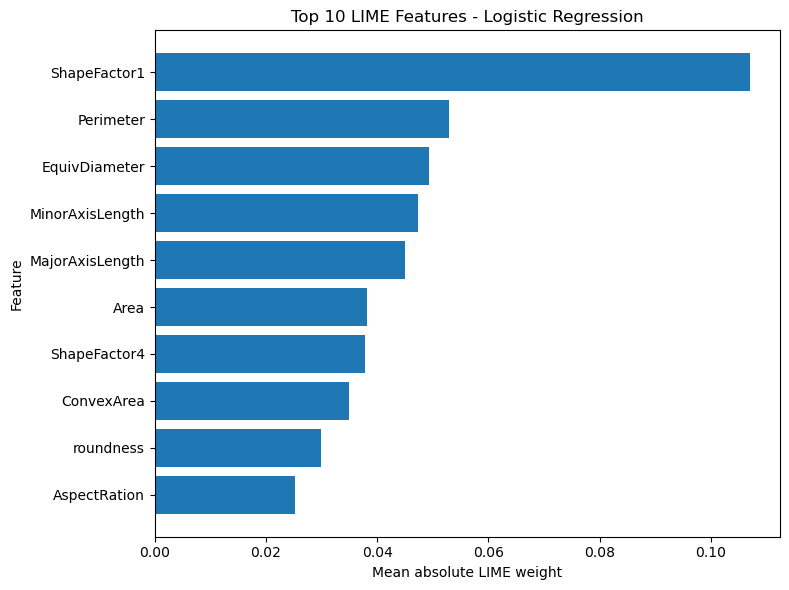

Saved LIME plot: /home/iailab42/khans1/projects/xai/plots/06_lime_explanations/lime_top_features_logistic_regression.png


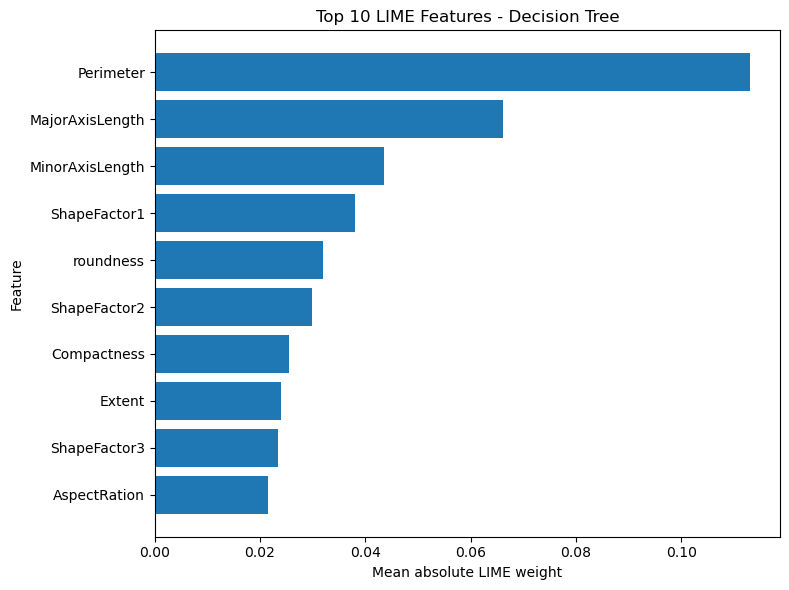

Saved LIME plot: /home/iailab42/khans1/projects/xai/plots/06_lime_explanations/lime_top_features_decision_tree.png


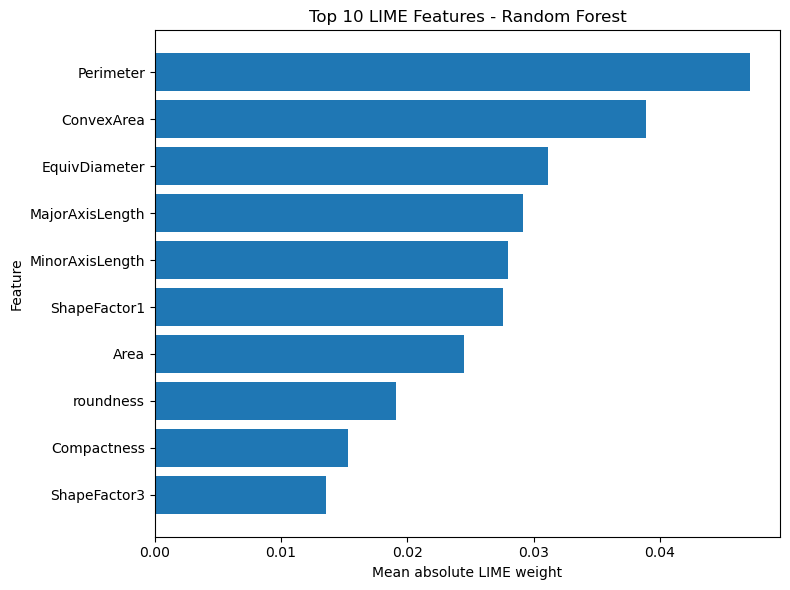

Saved LIME plot: /home/iailab42/khans1/projects/xai/plots/06_lime_explanations/lime_top_features_random_forest.png


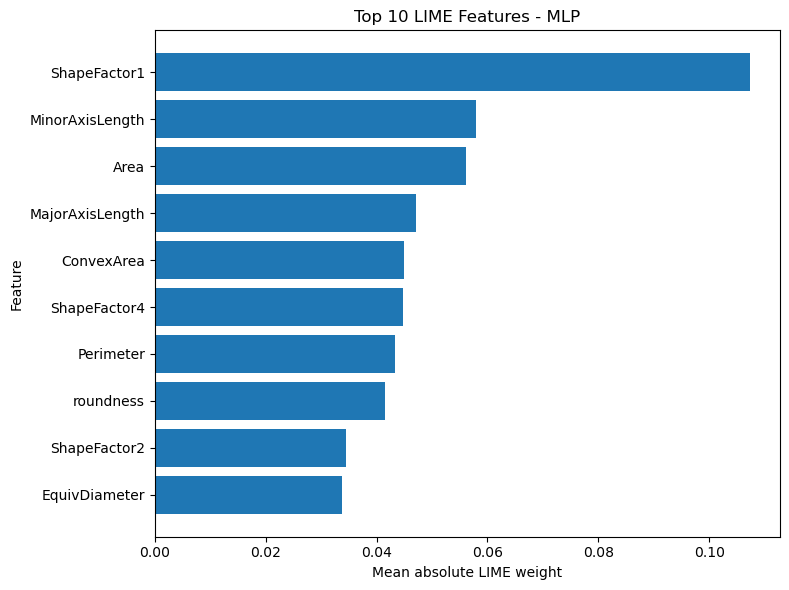

Saved LIME plot: /home/iailab42/khans1/projects/xai/plots/06_lime_explanations/lime_top_features_mlp.png


In [13]:
def plot_global_lime_bar(
    importance_df: pd.DataFrame,
    model_name: str,
    display_name: str,
    top_n: int = 10
):
    plot_df = importance_df.head(top_n).sort_values(
        by="mean_abs_lime_weight",
        ascending=True
    )

    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["mean_abs_lime_weight"])
    plt.xlabel("Mean absolute LIME weight")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} LIME Features - {display_name}")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"lime_top_features_{model_name}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_path


for model_name, model_info in models.items():
    model_importance = global_lime_importance[
        global_lime_importance["model_name"] == model_name
    ].sort_values(by="rank")

    plot_path = plot_global_lime_bar(
        importance_df=model_importance,
        model_name=model_name,
        display_name=model_info["display_name"],
        top_n=10
    )

    print(f"Saved LIME plot: {plot_path}")

### Cell 14 — Save LIME Summary JSON

In [14]:
lime_summary = {
    "notebook": NOTEBOOK_NAME,
    "random_state": RANDOM_STATE,
    "force_recompute_lime": FORCE_RECOMPUTE_LIME,
    "models_explained": list(models.keys()),
    "number_of_selected_samples": int(len(selected_samples)),
    "selected_samples_source": "results/05_shap_explanations/selected_samples.csv",
    "lime_num_samples": LIME_NUM_SAMPLES,
    "lime_num_features": int(num_lime_features),
    "top_k_local_features": TOP_K_LOCAL_FEATURES,
    "model_input_types": {
        model_name: model_input_data[model_name]["input_type"]
        for model_name in models.keys()
    },
    "saved_outputs": {
        "combined_local_lime_explanations": "results/06_lime_explanations/local_lime_explanations_all_models.csv",
        "top_k_local_lime_explanations": f"results/06_lime_explanations/local_lime_top_{TOP_K_LOCAL_FEATURES}_explanations_all_models.csv",
        "combined_global_lime_importance": "results/06_lime_explanations/lime_feature_importance_all_models.csv",
        "local_lime_explanations_per_model": [
            f"results/06_lime_explanations/local_lime_explanations_{model_name}.csv"
            for model_name in models.keys()
        ],
        "global_lime_importance_per_model": [
            f"results/06_lime_explanations/lime_feature_importance_{model_name}.csv"
            for model_name in models.keys()
        ],
        "raw_lime_records_per_model": [
            f"results/06_lime_explanations/lime_raw_explanations_{model_name}.pkl"
            for model_name in models.keys()
        ],
        "plots": [
            f"plots/06_lime_explanations/lime_top_features_{model_name}.png"
            for model_name in models.keys()
        ]
    }
}

summary_path = RESULTS_DIR / "lime_summary.json"
save_json(lime_summary, summary_path)

print(f"Saved LIME summary: {summary_path}")

Saved LIME summary: /home/iailab42/khans1/projects/xai/results/06_lime_explanations/lime_summary.json


In [15]:
print("Notebook 06 completed.")

print("\nSaved result files:")
for path in sorted(RESULTS_DIR.glob("*")):
    print(path.name)

print("\nSaved plot files:")
for path in sorted(PLOTS_DIR.glob("*")):
    print(path.name)

Notebook 06 completed.

Saved result files:
lime_feature_importance_all_models.csv
lime_feature_importance_decision_tree.csv
lime_feature_importance_logistic_regression.csv
lime_feature_importance_mlp.csv
lime_feature_importance_random_forest.csv
lime_raw_explanations_decision_tree.pkl
lime_raw_explanations_logistic_regression.pkl
lime_raw_explanations_mlp.pkl
lime_raw_explanations_random_forest.pkl
lime_summary.json
local_lime_explanations_all_models.csv
local_lime_explanations_decision_tree.csv
local_lime_explanations_logistic_regression.csv
local_lime_explanations_mlp.csv
local_lime_explanations_random_forest.csv
local_lime_top_5_explanations_all_models.csv

Saved plot files:
lime_top_features_decision_tree.png
lime_top_features_logistic_regression.png
lime_top_features_mlp.png
lime_top_features_random_forest.png
